In [1]:
import sys
sys.path.insert(0, "src")  # src/ contains core library modules

from instance_generator import InstanceGenerator

import pandas as pd
import seaborn as sns
from pprint import pprint
import pickle
import osmnx as ox
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp
import json
from farmers_intermediaries import Instance
from names_generator import generate_name

In [2]:
farmers_df = pd.read_csv('data/farmers.csv')
farmers_2_df = pd.read_csv('data/farmers_2.csv')
ints_df = pd.read_csv('data/ints.csv')

ig = InstanceGenerator(farmers_df, farmers_2_df, ints_df)

In [16]:
ints_list = ints_df.int_id.to_list()
ints_list.remove('Yaman Saragih')
ints_list.remove('Ndoharo')
ints_list

['Dodi Lesmana',
 'Purnomo',
 'Isna',
 'Agus Wibowo',
 'Nurmala',
 'yaya suhayat',
 'Agus Yasir',
 'Ngatinu',
 'Samsuri',
 'Riki Mandala',
 'Syafrial',
 'Khairul']

In [34]:
ig.gen_ints(12, 1)

gen_ints_list = list(ig.ints.keys())

int_to_type = {}
for i in range(len(ints_list)):
    true_int_type = ints_list[i]
    existing_type = gen_ints_list[i]
    ig.ints[gen_ints_list[i]]['type'] = true_int_type
    int_to_type[str(existing_type)] = true_int_type

print(int_to_type)
f_dfs = []

for j in range(50):
    instance = ig.gen_instance(j, j)
    f_df = pd.DataFrame(instance['farmers'])
    f_df['date'] = j
    f_df['type'] = f_df['intermediary'].map(lambda x: int_to_type[x])
    f_dfs.append(f_df)

synth_df = pd.concat(f_dfs)



{'friendly_johnson': 'Dodi Lesmana', 'stoic_williams': 'Purnomo', 'laughing_mestorf': 'Isna', 'competent_euclid': 'Agus Wibowo', 'objective_vaughan': 'Nurmala', 'vigilant_gould': 'yaya suhayat', 'gracious_sutherland': 'Agus Yasir', 'peaceful_kapitsa': 'Ngatinu', 'busy_easley': 'Samsuri', 'amazing_tu': 'Riki Mandala', 'quizzical_brahmagupta': 'Syafrial', 'eloquent_dirac': 'Khairul'}


In [35]:
synth_df

,id,location,quantity,intermediary,date,type
0,friendly_johnson_f0,"[-0.6789439108569242, 102.47029528277452]",2.0,friendly_johnson,0,Dodi Lesmana
1,stoic_williams_f0,"[-0.7398791476900523, 102.49725306320538]",2.1,stoic_williams,0,Purnomo
2,laughing_mestorf_f0,"[-0.3402986450870093, 102.46338607736234]",2.0,laughing_mestorf,0,Isna
3,competent_euclid_f0,"[-0.7060272574903712, 102.48152848321055]",1.7,competent_euclid,0,Agus Wibowo
4,competent_euclid_f1,"[-0.681208063228431, 102.46132606691148]",1.1,competent_euclid,0,Agus Wibowo
...,...,...,...,...,...,...
19,eloquent_dirac_f1,"[-0.4193019713839647, 102.49705619598855]",1.1,eloquent_dirac,49,Khairul
20,eloquent_dirac_f2,"[-0.4125410845199912, 102.47014242849531]",1.9,eloquent_dirac,49,Khairul
21,eloquent_dirac_f3,"[-0.43060024217318654, 102.474635627911]",1.0,eloquent_dirac,49,Khairul
22,eloquent_dirac_f4,"[-0.43058367385822155, 102.51051640927692]",1.4,eloquent_dirac,49,Khairul


In [36]:
synth_df.groupby(["type", "date"]).agg(
    daily_quantity=("quantity", "sum")
).groupby(["type"]).agg(
    mean_daily=("daily_quantity", "mean")
)

,mean_daily
type,
Agus Wibowo,5.590
Agus Yasir,3.742
Dodi Lesmana,3.382
Isna,3.390
Khairul,5.032
Ngatinu,3.272
Nurmala,4.718
Purnomo,4.342
Riki Mandala,3.972


In [5]:
farmers_2_df.groupby(["int_id", "date"]).agg(
    daily_quantity=("quantity", "sum")
).groupby(["int_id"]).agg(
    mean_daily=("daily_quantity", "mean")
)

,mean_daily
int_id,
Agus Wibowo,5.054545
Agus Yasir,3.700000
Dodi Lesmana,2.850000
Isna,3.354545
Khairul,4.384615
Ngatinu,3.200000
Nurmala,4.650000
Purnomo,4.108333
Riki Mandala,3.885714


In [6]:
farmers_df.groupby(["int_id", "date"]).agg(
    daily_quantity=("quantity", "sum")
).groupby(["int_id"]).agg(
    mean_daily=("daily_quantity", "mean")
)

,mean_daily
int_id,
Agus Wibowo,3.552778
Agus Yasir,2.548485
Dodi Lesmana,2.300000
Isna,3.673504
Khairul,2.670909
Ndoharo,2.668421
Ngatinu,2.631731
Nurmala,3.602721
Purnomo,3.663551


In [46]:
# Daily realized network: farmers served per day
daily_network = (
    synth_df
    .groupby(["type", "date"])
    .agg(
        daily_n_farmers=("id", "nunique"),
        daily_quantity=("quantity", "sum"),
    )
    .reset_index()
)

daily_summary = (
    daily_network
    .groupby("type")
    .agg(
        mean_daily_n_farmers=("daily_n_farmers", "mean"),
        median_daily_n_farmers=("daily_n_farmers", "median"),
        max_daily_n_farmers=("daily_n_farmers", "max"),
        mean_daily_quantity=("daily_quantity", "mean"),
        max_daily_quantity=("daily_quantity", "max"),
        n_days=("date", "nunique"),
    )
    .reset_index()
)

daily_summary.sort_values("mean_daily_n_farmers", ascending=False)

,type,mean_daily_n_farmers,median_daily_n_farmers,max_daily_n_farmers,mean_daily_quantity,max_daily_quantity,n_days
4,Khairul,4.44,4.0,8,5.032,8.8,50
6,Nurmala,3.14,3.0,7,4.718,8.9,50
0,Agus Wibowo,2.74,3.0,5,5.590,8.9,50
8,Riki Mandala,2.70,3.0,7,3.972,8.9,50
7,Purnomo,2.58,1.0,6,4.342,8.9,50
2,Dodi Lesmana,2.10,2.0,3,3.382,7.0,50
5,Ngatinu,2.04,2.0,4,3.272,7.9,50
1,Agus Yasir,2.00,2.0,3,3.742,7.0,50
10,Syafrial,1.74,2.0,3,2.684,6.0,50
3,Isna,1.60,1.0,3,3.390,8.4,50


In [ ]:
# Daily realized network: farmers served per day
daily_network = (
    farmers_2_df
    .groupby(["int_id", "date"])
    .agg(
        daily_n_farmers=("farmer_id", "nunique"),
        daily_quantity=("quantity", "sum"),
    )
    .reset_index()
)

daily_summary = (
    daily_network
    .groupby("int_id")
    .agg(
        mean_daily_n_farmers=("daily_n_farmers", "mean"),
        median_daily_n_farmers=("daily_n_farmers", "median"),
        max_daily_n_farmers=("daily_n_farmers", "max"),
        mean_daily_quantity=("daily_quantity", "mean"),
        max_daily_quantity=("daily_quantity", "max"),
        n_days=("date", "nunique"),
    )
    .reset_index()
)

# Relationship breadth: distinct farmers ever observed with each intermediary
relationship_breadth = (
    farmers_df
    .drop_duplicates(["int_id", "farmer_x", "farmer_y"])
    .groupby("int_id")
    .size()
    .reset_index(name="n_unique_farmer_locations_ever")
)

In [45]:
network_summary = (
    daily_summary
    .merge(relationship_breadth, on="int_id", how="left", suffixes=("", "_breadth"))
)

network_summary.sort_values("mean_daily_n_farmers", ascending=False)

,int_id,mean_daily_n_farmers,median_daily_n_farmers,max_daily_n_farmers,mean_daily_quantity,max_daily_quantity,n_days,n_unique_farmer_locations_ever
4,Khairul,4.076923,4.0,8,4.384615,8.7,13,33
6,Nurmala,3.000000,2.5,7,4.650000,8.8,12,28
0,Agus Wibowo,2.727273,3.0,5,5.054545,8.8,11,22
8,Riki Mandala,2.642857,3.0,7,3.885714,8.6,14,30
7,Purnomo,2.500000,1.5,6,4.108333,8.7,12,25
5,Ngatinu,2.100000,2.0,4,3.200000,8.0,10,19
1,Agus Yasir,2.000000,2.0,3,3.700000,6.1,10,18
2,Dodi Lesmana,1.833333,2.0,3,2.850000,6.4,12,17
10,Syafrial,1.833333,2.0,3,2.466667,4.4,12,13
11,yaya suhayat,1.666667,2.0,2,4.200000,5.3,3,3


In [43]:
import pandas as pd
import numpy as np

# Number of farmers served by each intermediary type on each day
daily_network_sizes = (
    farmers_df
    .groupby(["int_id", "date"])
    .agg(
        n_farmers=("farmer_id", "nunique"),  # use size if no farmer_id column
        total_quantity=("quantity", "sum"),
    )
    .reset_index()
)

# Summary by intermediary type
type_network_summary = (
    daily_network_sizes
    .groupby("int_id")
    .agg(
        mean_n_farmers=("n_farmers", "mean"),
        median_n_farmers=("n_farmers", "median"),
        min_n_farmers=("n_farmers", "min"),
        max_n_farmers=("n_farmers", "max"),
        sd_n_farmers=("n_farmers", "std"),
        mean_total_quantity=("total_quantity", "mean"),
        n_days=("date", "nunique"),
    )
    .reset_index()
    .sort_values("mean_n_farmers", ascending=False)
)

type_network_summary

,int_id,mean_n_farmers,median_n_farmers,min_n_farmers,max_n_farmers,sd_n_farmers,mean_total_quantity,n_days
8,Purnomo,2.261682,2.0,1,8,1.580163,3.663551,107
4,Khairul,2.254545,2.0,1,9,1.616636,2.670909,110
5,Ndoharo,2.210526,2.0,1,6,1.397575,2.668421,19
7,Nurmala,2.074830,1.0,1,9,1.676136,3.602721,147
9,Riki Mandala,1.949153,1.0,1,7,1.298037,2.973446,177
0,Agus Wibowo,1.902778,2.0,1,6,1.190401,3.552778,144
3,Isna,1.871795,1.0,1,6,1.171048,3.673504,117
13,yaya suhayat,1.814516,2.0,1,6,1.107013,3.243548,124
11,Syafrial,1.700000,1.0,1,6,0.996604,2.995000,60
12,Yaman Saragih,1.619048,1.0,1,4,0.920662,4.195238,21


In [44]:
import pandas as pd
import numpy as np

# Number of farmers served by each intermediary type on each day
daily_network_sizes = (
    farmers_2_df
    .groupby(["int_id", "date"])
    .agg(
        n_farmers=("farmer_id", "nunique"),  # use size if no farmer_id column
        total_quantity=("quantity", "sum"),
    )
    .reset_index()
)

# Summary by intermediary type
type_network_summary = (
    daily_network_sizes
    .groupby("int_id")
    .agg(
        mean_n_farmers=("n_farmers", "mean"),
        median_n_farmers=("n_farmers", "median"),
        min_n_farmers=("n_farmers", "min"),
        max_n_farmers=("n_farmers", "max"),
        sd_n_farmers=("n_farmers", "std"),
        mean_total_quantity=("total_quantity", "mean"),
        n_days=("date", "nunique"),
    )
    .reset_index()
    .sort_values("mean_n_farmers", ascending=False)
)

type_network_summary

,int_id,mean_n_farmers,median_n_farmers,min_n_farmers,max_n_farmers,sd_n_farmers,mean_total_quantity,n_days
4,Khairul,4.076923,4.0,1,8,1.754116,4.384615,13
6,Nurmala,3.000000,2.5,1,7,2.000000,4.650000,12
0,Agus Wibowo,2.727273,3.0,1,5,1.103713,5.054545,11
8,Riki Mandala,2.642857,3.0,1,7,1.598420,3.885714,14
7,Purnomo,2.500000,1.5,1,6,1.882938,4.108333,12
5,Ngatinu,2.100000,2.0,1,4,0.994429,3.200000,10
1,Agus Yasir,2.000000,2.0,1,3,0.816497,3.700000,10
2,Dodi Lesmana,1.833333,2.0,1,3,0.717741,2.850000,12
10,Syafrial,1.833333,2.0,1,3,0.717741,2.466667,12
11,yaya suhayat,1.666667,2.0,1,2,0.577350,4.200000,3


In [8]:
seed = 339
ig.gen_ints(10, seed, "high")
instance = ig.gen_instance(1, seed)
print(len(instance['farmers']))
pprint(instance['farmers'])

41
[{'id': 'cool_leavitt_f0',
  'intermediary': 'cool_leavitt',
  'location': [-0.34256850859834226, 102.42974735114379],
  'quantity': 1.9},
 {'id': 'cool_leavitt_f1',
  'intermediary': 'cool_leavitt',
  'location': [-0.36287706182361074, 102.45890919432264],
  'quantity': 0.8},
 {'id': 'cool_leavitt_f2',
  'intermediary': 'cool_leavitt',
  'location': [-0.37192100178355536, 102.42527287014038],
  'quantity': 0.9},
 {'id': 'cool_leavitt_f3',
  'intermediary': 'cool_leavitt',
  'location': [-0.36965185964990543, 102.45442655740563],
  'quantity': 1.7},
 {'id': 'vigorous_euclid_f0',
  'intermediary': 'vigorous_euclid',
  'location': [-0.3606142190573031, 102.4723639062176],
  'quantity': 2.0},
 {'id': 'affectionate_chebyshev_f0',
  'intermediary': 'affectionate_chebyshev',
  'location': [-0.39671170131794226, 102.53068375636207],
  'quantity': 1.5},
 {'id': 'affectionate_chebyshev_f1',
  'intermediary': 'affectionate_chebyshev',
  'location': [-0.38318426143633705, 102.48807069705212],


In [18]:
from datetime import datetime, timedelta
start_date = datetime.strptime("2020-05-01", "%Y-%m-%d")
end_date = datetime.strptime("2021-04-30", "%Y-%m-%d")
date_list = [(start_date + timedelta(days=x)).strftime("%Y-%m-%d") for x in range((end_date - start_date).days + 1)]

synthetic_seeds = list(range(50))

summary = compare_real_vs_synthetic_total_fruit_value(
    real_instance_strs=date_list,
    synthetic_generator=ig,
    synthetic_seeds=synthetic_seeds,
    scale_factor=1.0,
)

for k, v in summary.items():
    if not isinstance(v, np.ndarray):
        print(f"{k}: {v}")

UnboundLocalError: cannot access local variable 'mill' where it is not associated with a value

In [12]:
import numpy as np
from farmers_intermediaries import Instance


def get_instance_activity_stats(instance):
    int_to_farmers = {
        intermediary.id: []
        for intermediary in instance.intermediaries
    }

    for farmer in instance.farmers:
        int_id = farmer.additional_info["intermediary_id"]
        int_to_farmers[int_id].append(farmer)

    active_ints = {
        int_id: farmers
        for int_id, farmers in int_to_farmers.items()
        if len(farmers) > 0
    }

    total_q = sum(f.quantity for f in instance.farmers)
    n_active_ints = len(active_ints)
    n_farmers = len(instance.farmers)

    return {
        "total_quantity": total_q,
        "n_intermediaries": len(instance.intermediaries),
        "n_active_intermediaries": n_active_ints,
        "active_share": n_active_ints / len(instance.intermediaries)
        if len(instance.intermediaries) > 0 else np.nan,
        "n_farmers": n_farmers,
        "farmers_per_active_intermediary": n_farmers / n_active_ints
        if n_active_ints > 0 else np.nan,
        "quantity_per_farmer": total_q / n_farmers
        if n_farmers > 0 else np.nan,
        "quantity_per_active_intermediary": total_q / n_active_ints
        if n_active_ints > 0 else np.nan,
    }


def summarize_activity_stats(instances):
    stats = [get_instance_activity_stats(instance) for instance in instances]
    keys = stats[0].keys()

    return {
        key: np.nanmean([s[key] for s in stats])
        for key in keys
    }


def compare_real_vs_synthetic_activity_stats(
    real_instance_strs,
    synthetic_generator,
    synthetic_seeds,
    scale_factor=1.0,
):
    real_instances = [
        Instance.from_yaml(f"../FactoredPlatformSolver/data/instances/{s}.yaml")
        for s in real_instance_strs
    ]

    synthetic_instances = []

    for seed in synthetic_seeds:
        synthetic_generator.gen_ints(14, seed)
        instance_dict = synthetic_generator.gen_instance(
            instance_id=f"synthetic_{seed}",
            seed=seed,
            write=False,
            plot=False,
            scale_factor=scale_factor,
        )
        synthetic_instances.append(Instance.from_dict(instance_dict))

    real_summary = summarize_activity_stats(real_instances)
    synthetic_summary = summarize_activity_stats(synthetic_instances)

    comparison = {}

    for key in real_summary:
        real_val = real_summary[key]
        synthetic_val = synthetic_summary[key]

        comparison[key] = {
            "real_avg": real_val,
            "synthetic_avg": synthetic_val,
            "diff": synthetic_val - real_val,
            "pct_diff": synthetic_val / real_val - 1
            if real_val not in [0, np.nan] and not np.isnan(real_val)
            else np.nan,
        }

    return comparison

In [13]:
activity_comparison = compare_real_vs_synthetic_activity_stats(
    real_instance_strs=date_list,
    synthetic_generator=ig,
    synthetic_seeds=list(range(50)),
    scale_factor=1.0,
)

for stat, vals in activity_comparison.items():
    print(stat)
    for k, v in vals.items():
        print(f"  {k}: {v}")

total_quantity
  real_avg: 36.15714285714286
  synthetic_avg: 25.244
  diff: -10.913142857142859
  pct_diff: -0.3018253654681944
n_intermediaries
  real_avg: 14.0
  synthetic_avg: 14.0
  diff: 0.0
  pct_diff: 0.0
n_active_intermediaries
  real_avg: 9.142857142857142
  synthetic_avg: 7.46
  diff: -1.6828571428571424
  pct_diff: -0.1840624999999999
active_share
  real_avg: 0.6530612244897959
  synthetic_avg: 0.5328571428571428
  diff: -0.12020408163265306
  pct_diff: -0.18406250000000002
n_farmers
  real_avg: 23.214285714285715
  synthetic_avg: 14.12
  diff: -9.094285714285716
  pct_diff: -0.39175384615384623
farmers_per_active_intermediary
  real_avg: 2.532542259327974
  synthetic_avg: 1.8746118326118326
  diff: -0.6579304267161414
  pct_diff: -0.2597905027222438
quantity_per_farmer
  real_avg: 1.5591738661276477
  synthetic_avg: 1.818505585045716
  diff: 0.25933171891806817
  pct_diff: 0.16632636330811668
quantity_per_active_intermediary
  real_avg: 3.9448554421768702
  synthetic_avg: 

In [3]:
seed = 10
N_INTS = 14

ig.ints = {}

for _, row in ints_df.iterrows():
    int_id = row['int_id']
    xy = (row['int_x'], row['int_y'])
    ll = (row['int_lat'], row['int_lon'])
    type = int_id

    ig.ints[int_id] = {
        'xy': xy,
        'll': ll,
        'type': type
    }
# instance = ig.gen_instance(1, seed, write=False, plot=False)


In [5]:
MAX_CAPACITY = 9
MIN_CAPACITY = 4

def instance_to_dfs(instance):
    # Process Farmers
    df_farmers = pd.DataFrame(instance['farmers'])
    df_farmers['farmer_lat'] = df_farmers['location'].apply(lambda x: x[0])
    df_farmers['farmer_lon'] = df_farmers['location'].apply(lambda x: x[1])
    df_farmers['farmer_x'], df_farmers['farmer_y'] = ig.ll_to_xy.transform(
        df_farmers.farmer_lon.values, df_farmers.farmer_lat.values)
    
    df_farmers.drop('location', axis=1)

    # Add a column to identify which intermediary they belong to
    df_farmers['int_id'] = df_farmers['id'].apply(lambda x: x.split('_')[0])

    # Process Intermediaries
    df_ints = pd.DataFrame(instance['intermediaries'])
    df_ints['int_lat'] = df_ints['location'].apply(lambda x: x[0])
    df_ints['int_lon'] = df_ints['location'].apply(lambda x: x[1])
    df_ints['int_x'], df_ints['int_y'] = ig.ll_to_xy.transform(
        df_ints.int_lon.values, df_ints.int_lat.values)
    
    df_ints.drop('location', axis=1)

    df_combined = df_farmers.merge(df_ints, how='left', left_on='int_id', right_on='id')

    df_combined['distance'] = np.sqrt((df_combined.farmer_x - df_combined.int_x) ** 2 + (df_combined.farmer_y - df_combined.int_y) ** 2)
    
    return df_combined

In [8]:
N_CYCLES = 5
HARVEST_CYCLE = 10 # Days in one full rotation


all_cycles = []

for k in range(HARVEST_CYCLE * N_CYCLES):
    instance = ig.gen_instance(k, k, plot=False, write=False)
    df = instance_to_dfs(instance)
    df['date'] = k
    all_cycles.append(df)


# Final formatting
df = pd.concat(all_cycles)

df.sort_values(by=['int_id', 'date'], inplace=True)
df.rename(columns={'id': 'farmer_id'}, inplace=True)

### How many farmers are in each intermediary's network?

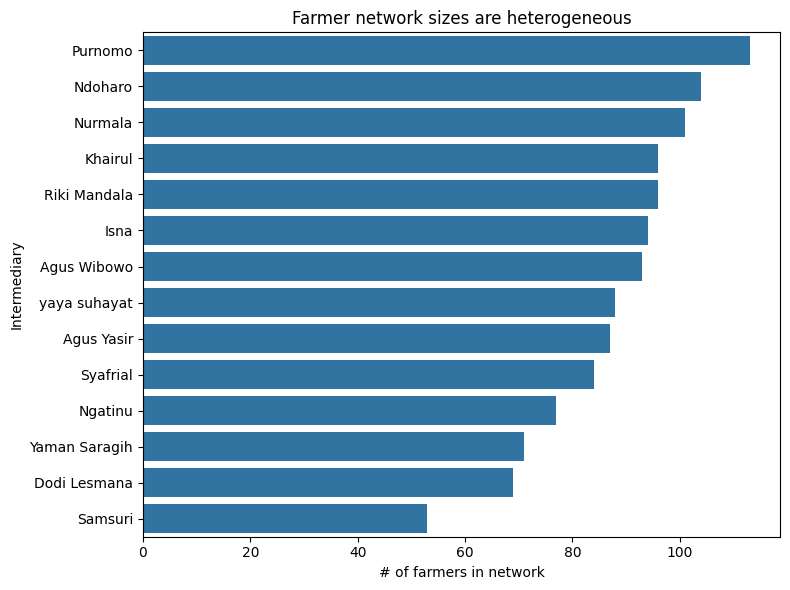

In [9]:
df_1 = df.copy()
res_1 = df_1.drop_duplicates(['int_id', 'farmer_x', 'farmer_y']).groupby('int_id').size()
res_1.sort_values(inplace=True, ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=res_1.values, y=res_1.index)

plt.ylabel('Intermediary')
plt.xlabel('# of farmers in network')
plt.title('Farmer network sizes are heterogeneous')

plt.tight_layout()
plt.show()

### Verify: n_farmers matches (by type)

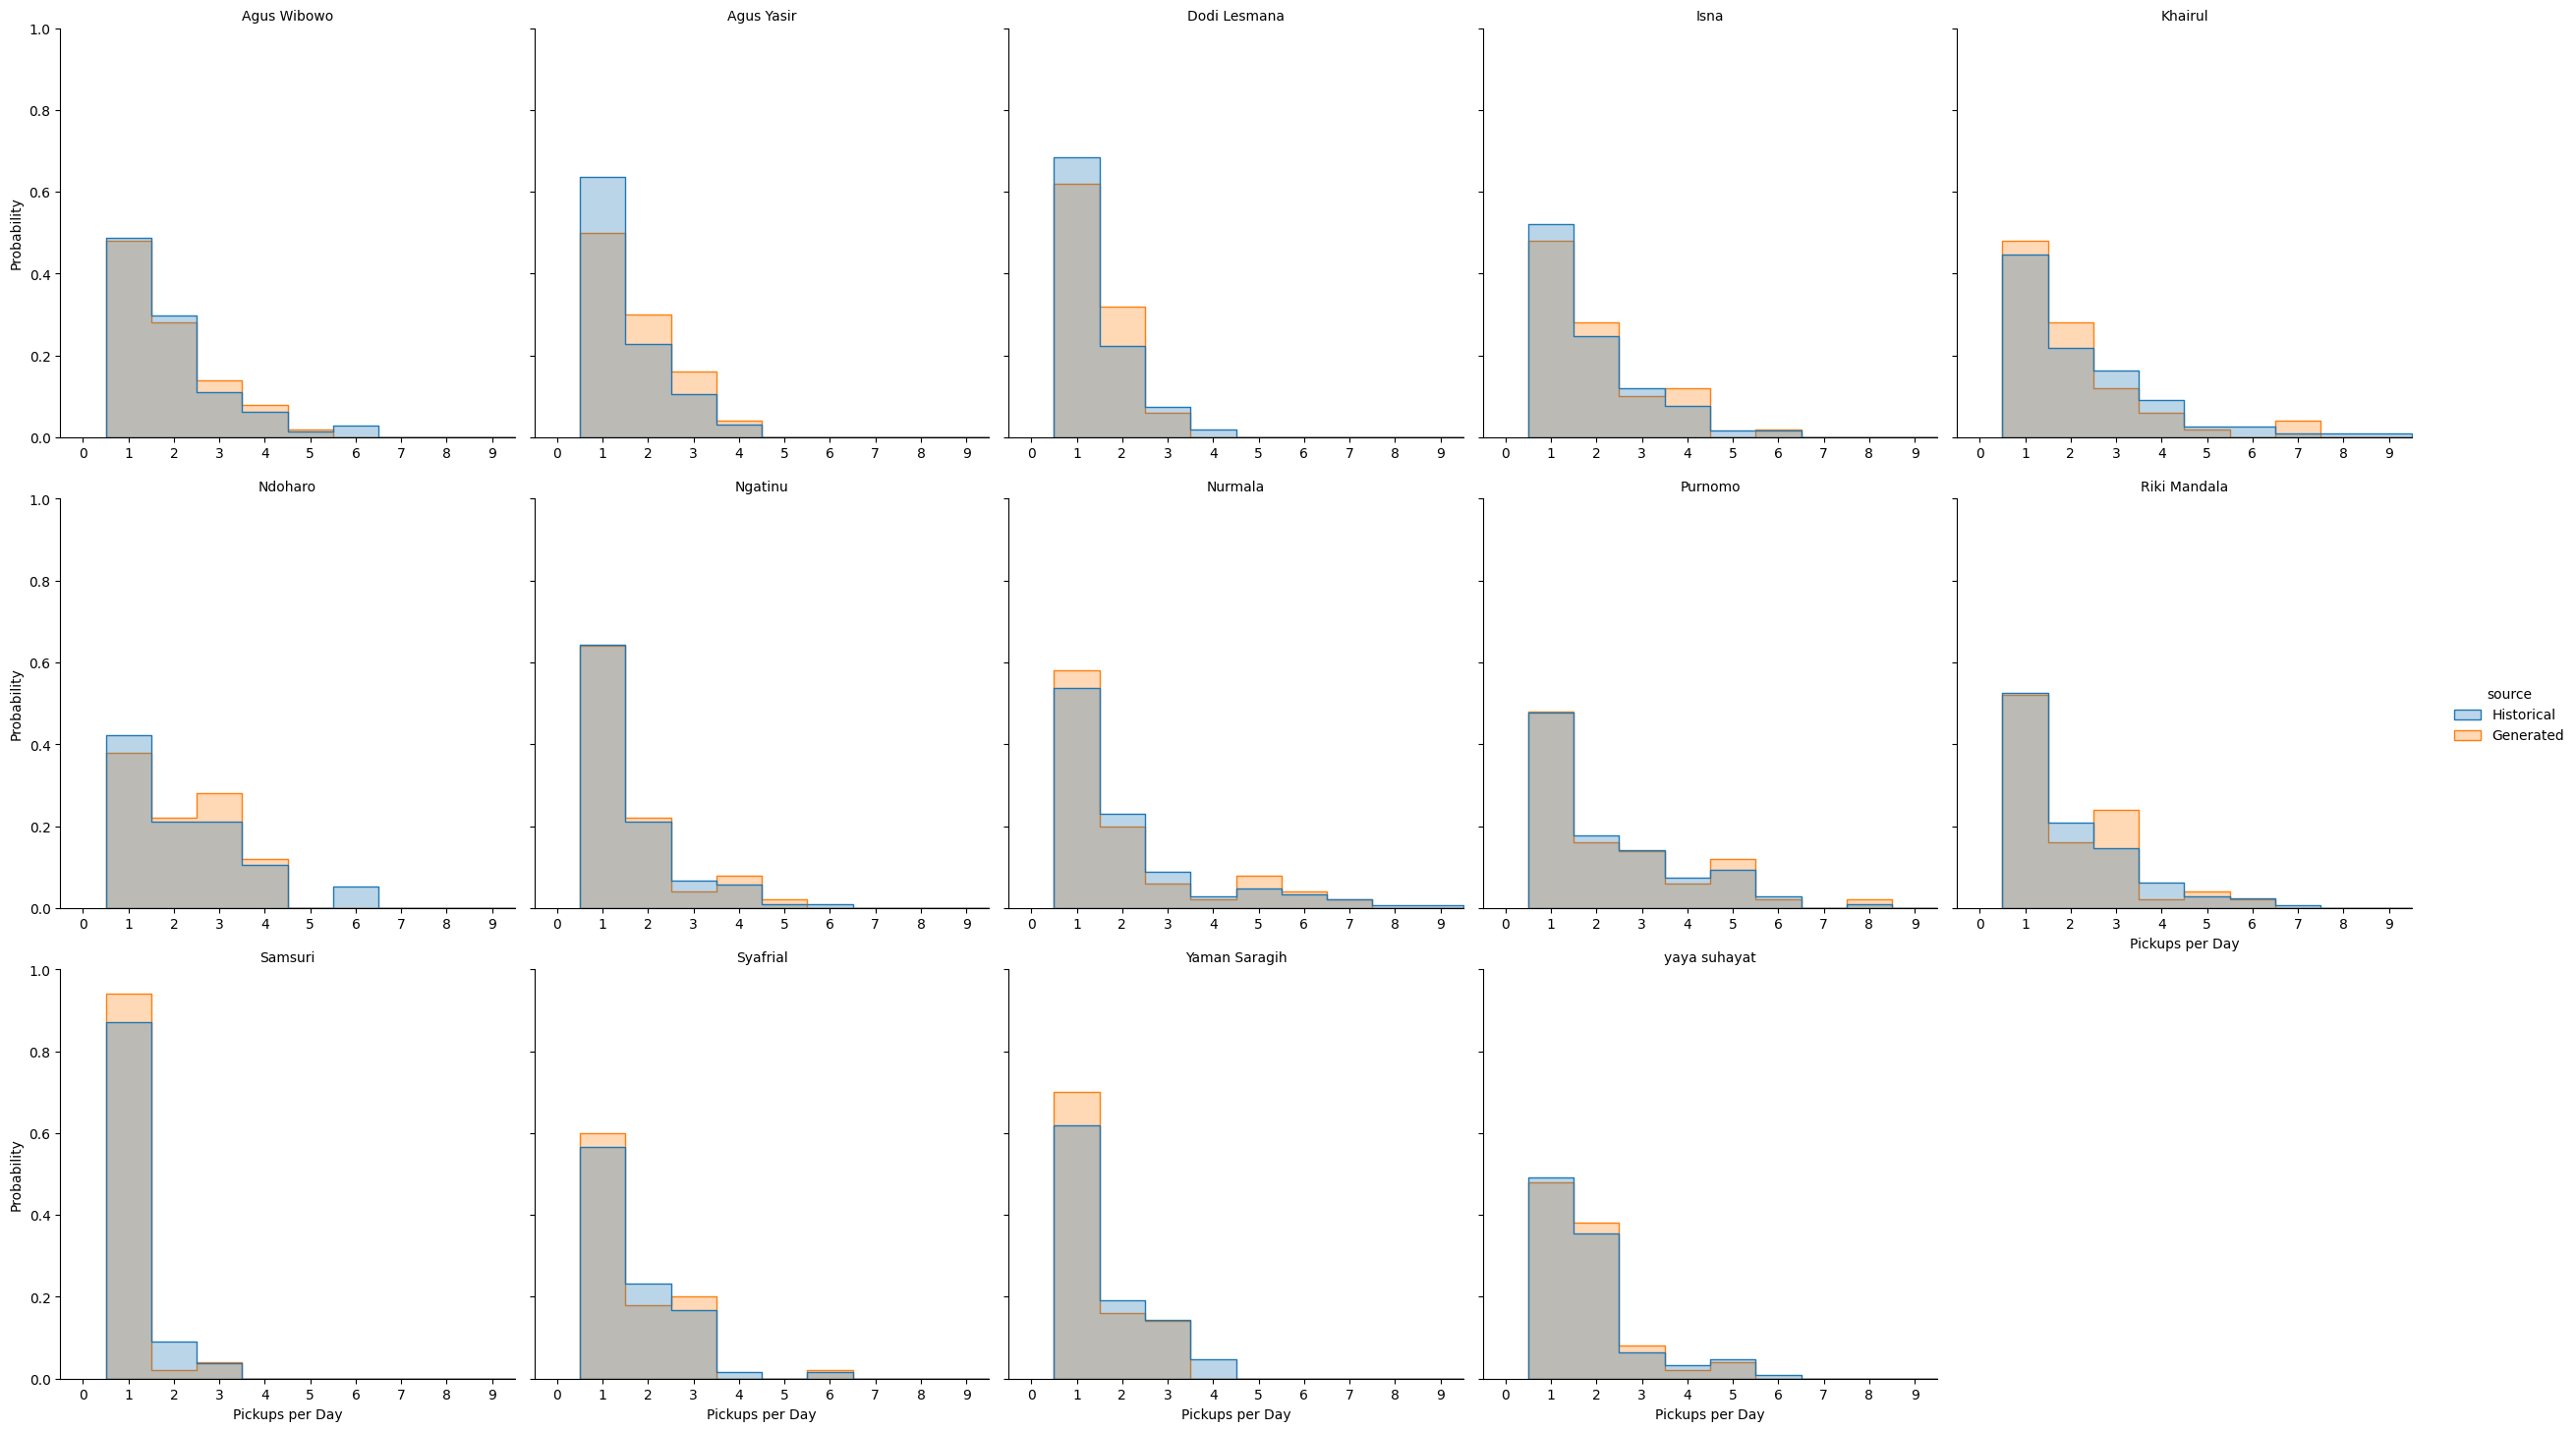

In [10]:
pickups_hist = farmers_df.groupby(['int_id', 'date']).size().reset_index(name='count')
pickups_hist['source'] = 'Historical'

pickups_gen = df.groupby(['int_id', 'date']).size().reset_index(name='count')
pickups_gen['source'] = 'Generated'

df_combined = pd.concat([pickups_hist, pickups_gen], ignore_index=True)

max_count = df_combined['count'].max()
bins = np.arange(-0.5, max_count + 1.5, 1)

g = sns.displot(
    data=df_combined,
    x='count',
    hue='source',          # This creates the overlay
    col='int_id',
    col_wrap=5,
    bins=bins,
    discrete=True,
    stat='probability',
    common_norm=False,     # Ensures each source's bars sum to 1 within the facet
    element='step',        # 'step' makes overlays much easier to read
    alpha=0.3,             # Transparency for the fill
    facet_kws={
        'sharex': True,
        'sharey': True
    }
)

xticks = np.arange(0, max_count + 1)
for ax in g.axes.flatten():
    ax.set_xticks(xticks)
    ax.set_xlim(-0.5, max_count + 0.5)
    ax.tick_params(labelbottom=True)

g.set(ylim=(0, 1))
g.set_titles("{col_name}")
g.figure.subplots_adjust(hspace=0.15)
g.set_axis_labels("Pickups per Day", "Probability")

# g.figure.suptitle('Distribution of # of farmers picked up (by intermediary)', fontsize=14)
g.figure.subplots_adjust(top=0.955)

plt.show()

### Verify: quantity distributions match (by type)

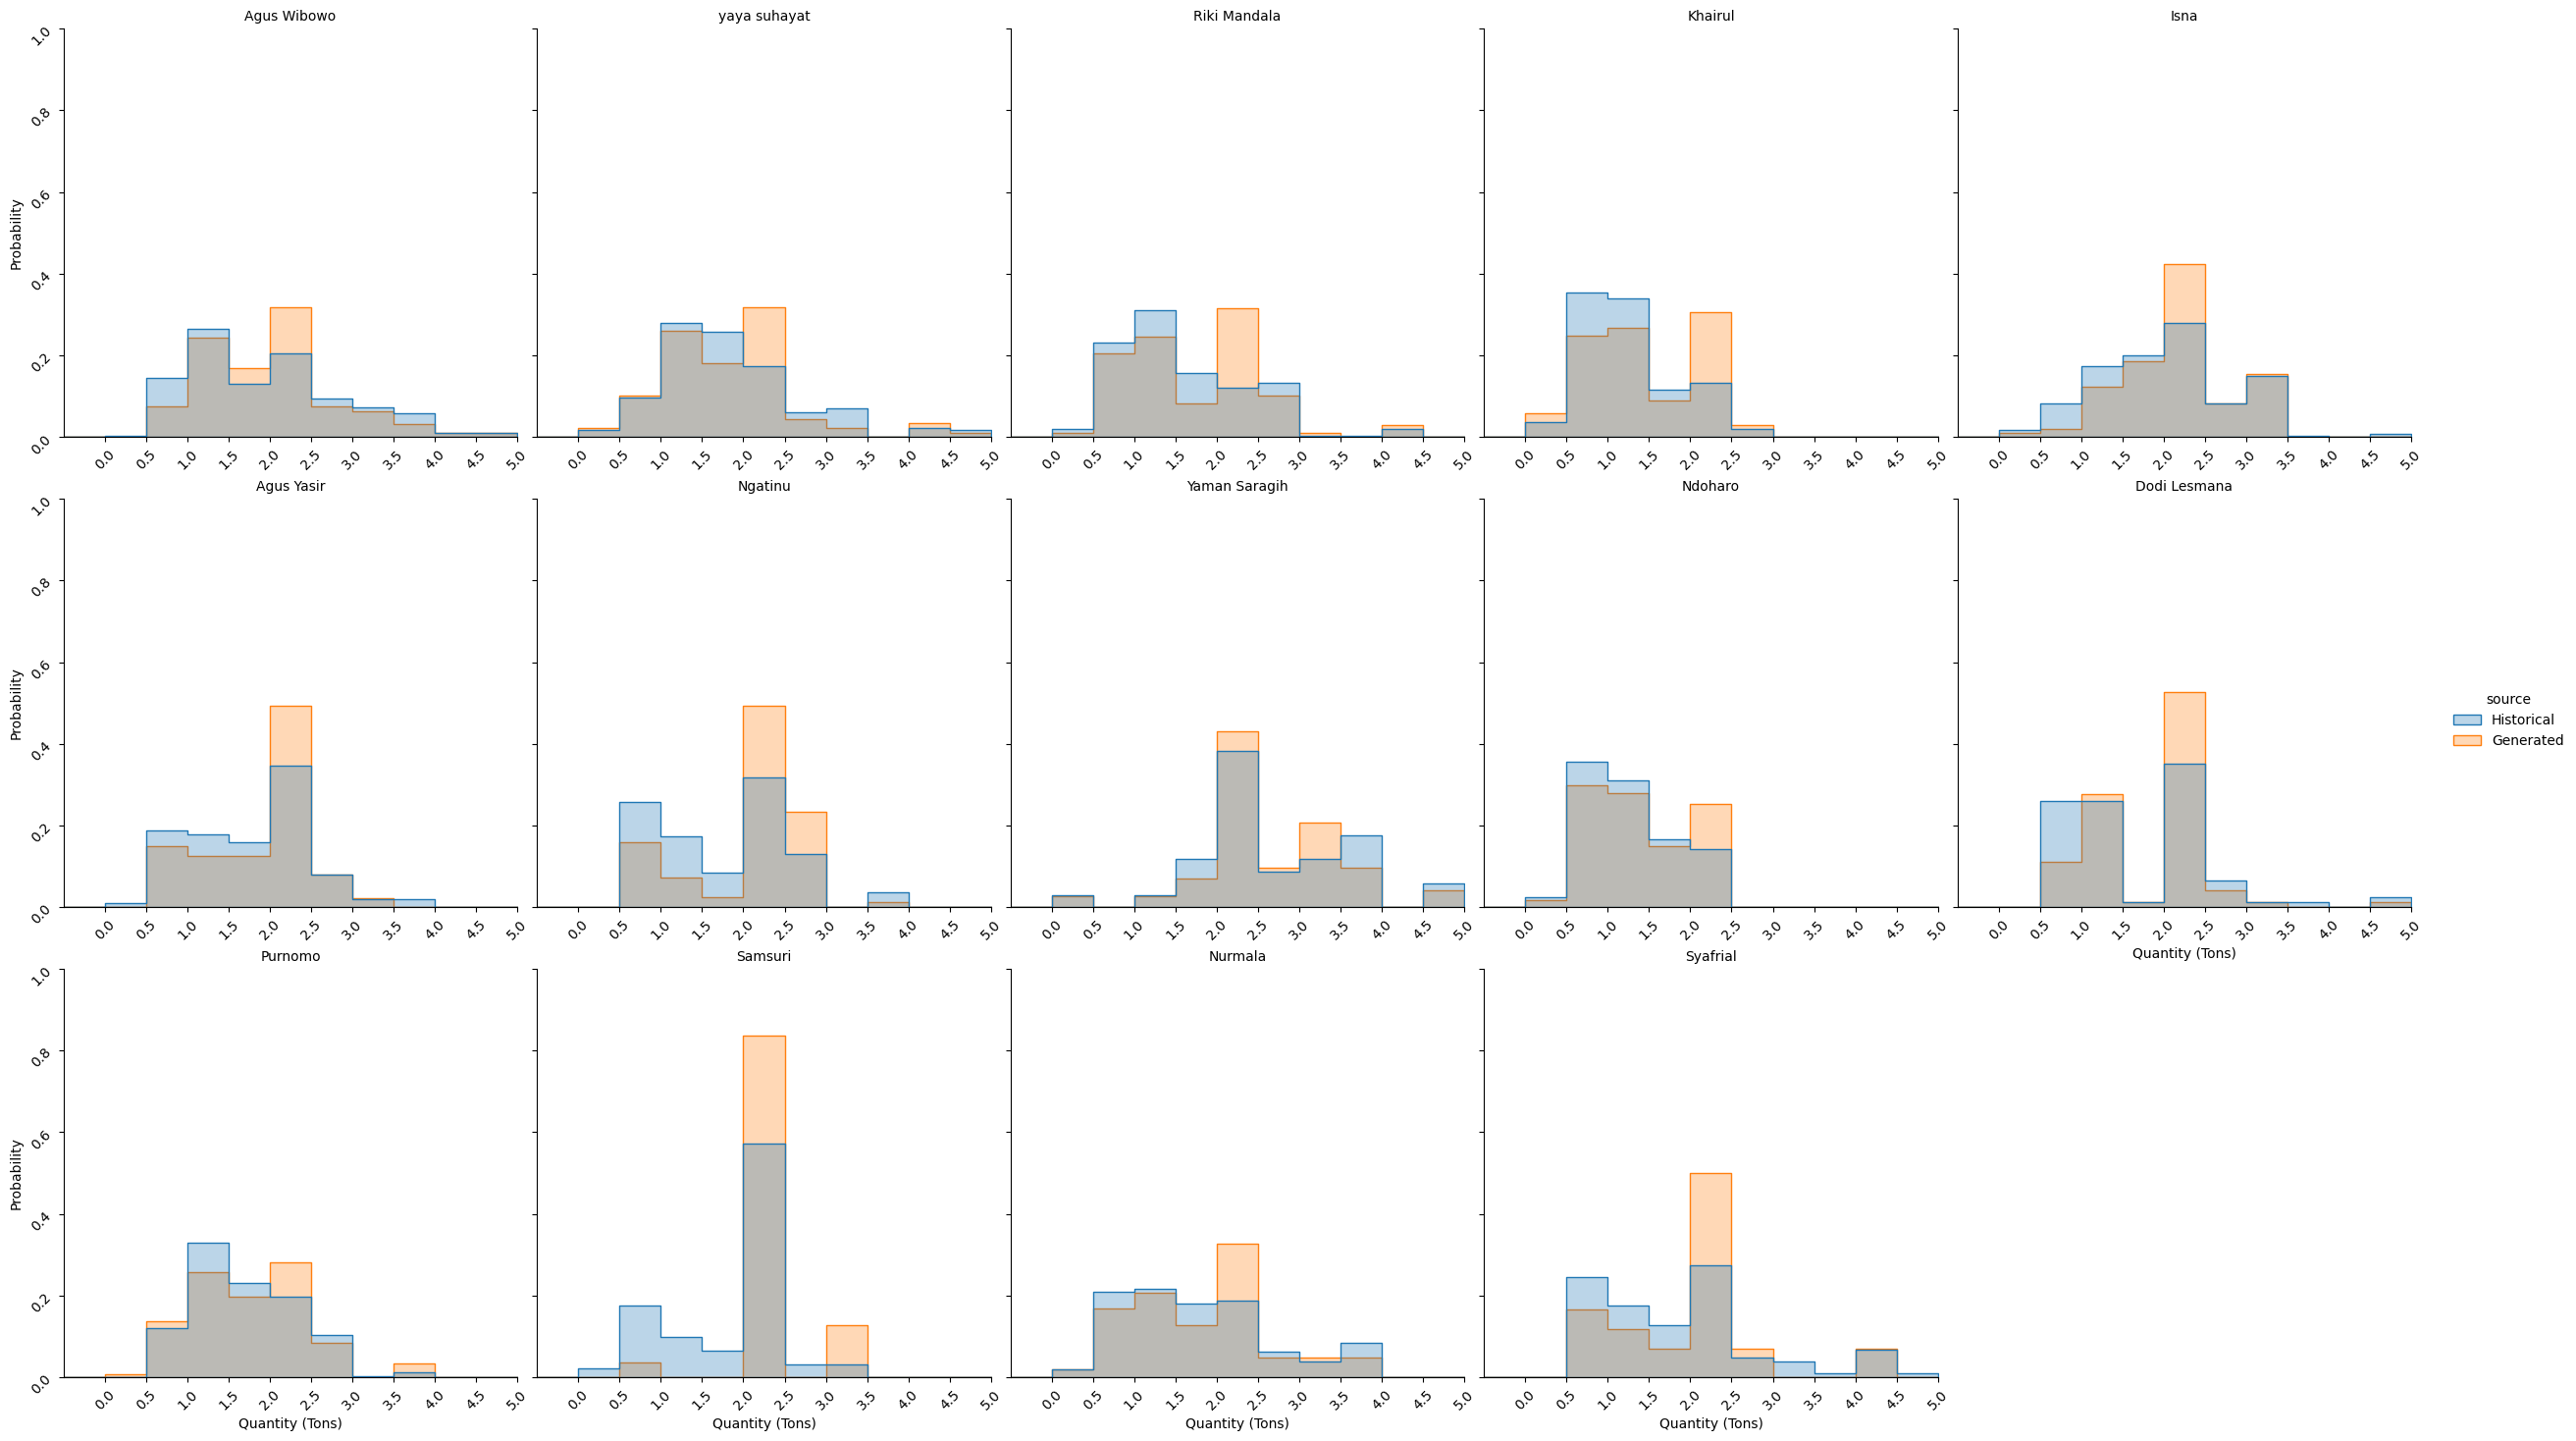

In [11]:
# 1. Prepare the two datasets
df_hist = farmers_df[['int_id', 'quantity']].copy()
df_hist['source'] = 'Historical'

df_gen = df[['int_id', 'quantity']].copy()
df_gen['source'] = 'Generated'

# 2. Combine them
df_combined = pd.concat([df_hist, df_gen], ignore_index=True)

# 3. Define Bins (shared for both)
max_q = df_combined['quantity'].max()
bins = np.arange(-0.5, max_q + 1.5, 0.5)

# 4. Plot using displot
g = sns.displot(
    data=df_combined,
    x='quantity',
    hue='source',
    col='int_id',
    col_wrap=5,
    bins=bins,
    stat='probability',
    common_norm=False,
    element='step',       # Highly recommended for overlays
    alpha=0.3,
    facet_kws={
        'sharex': True,
        'sharey': True
    }
)

# 5. Axis Formatting
xticks = np.arange(0, max_q + 1, 0.5)
for ax in g.axes.flatten():
    ax.set_xticks(xticks)
    ax.set_xlim(-0.5, max_q + 0.5)
    ax.tick_params(labelbottom=True, rotation=45) # Rotate for readability

g.set(ylim=(0, 1))
g.set_titles("{col_name}")
g.set_axis_labels("Quantity (Tons)", "Probability")

g.figure.subplots_adjust(hspace=0.15)

# g.figure.suptitle('Distribution of quantity (by intermediary)', fontsize=14)
g.figure.subplots_adjust(top=0.955)
plt.show()

### Verify farmer-intermediary distances match

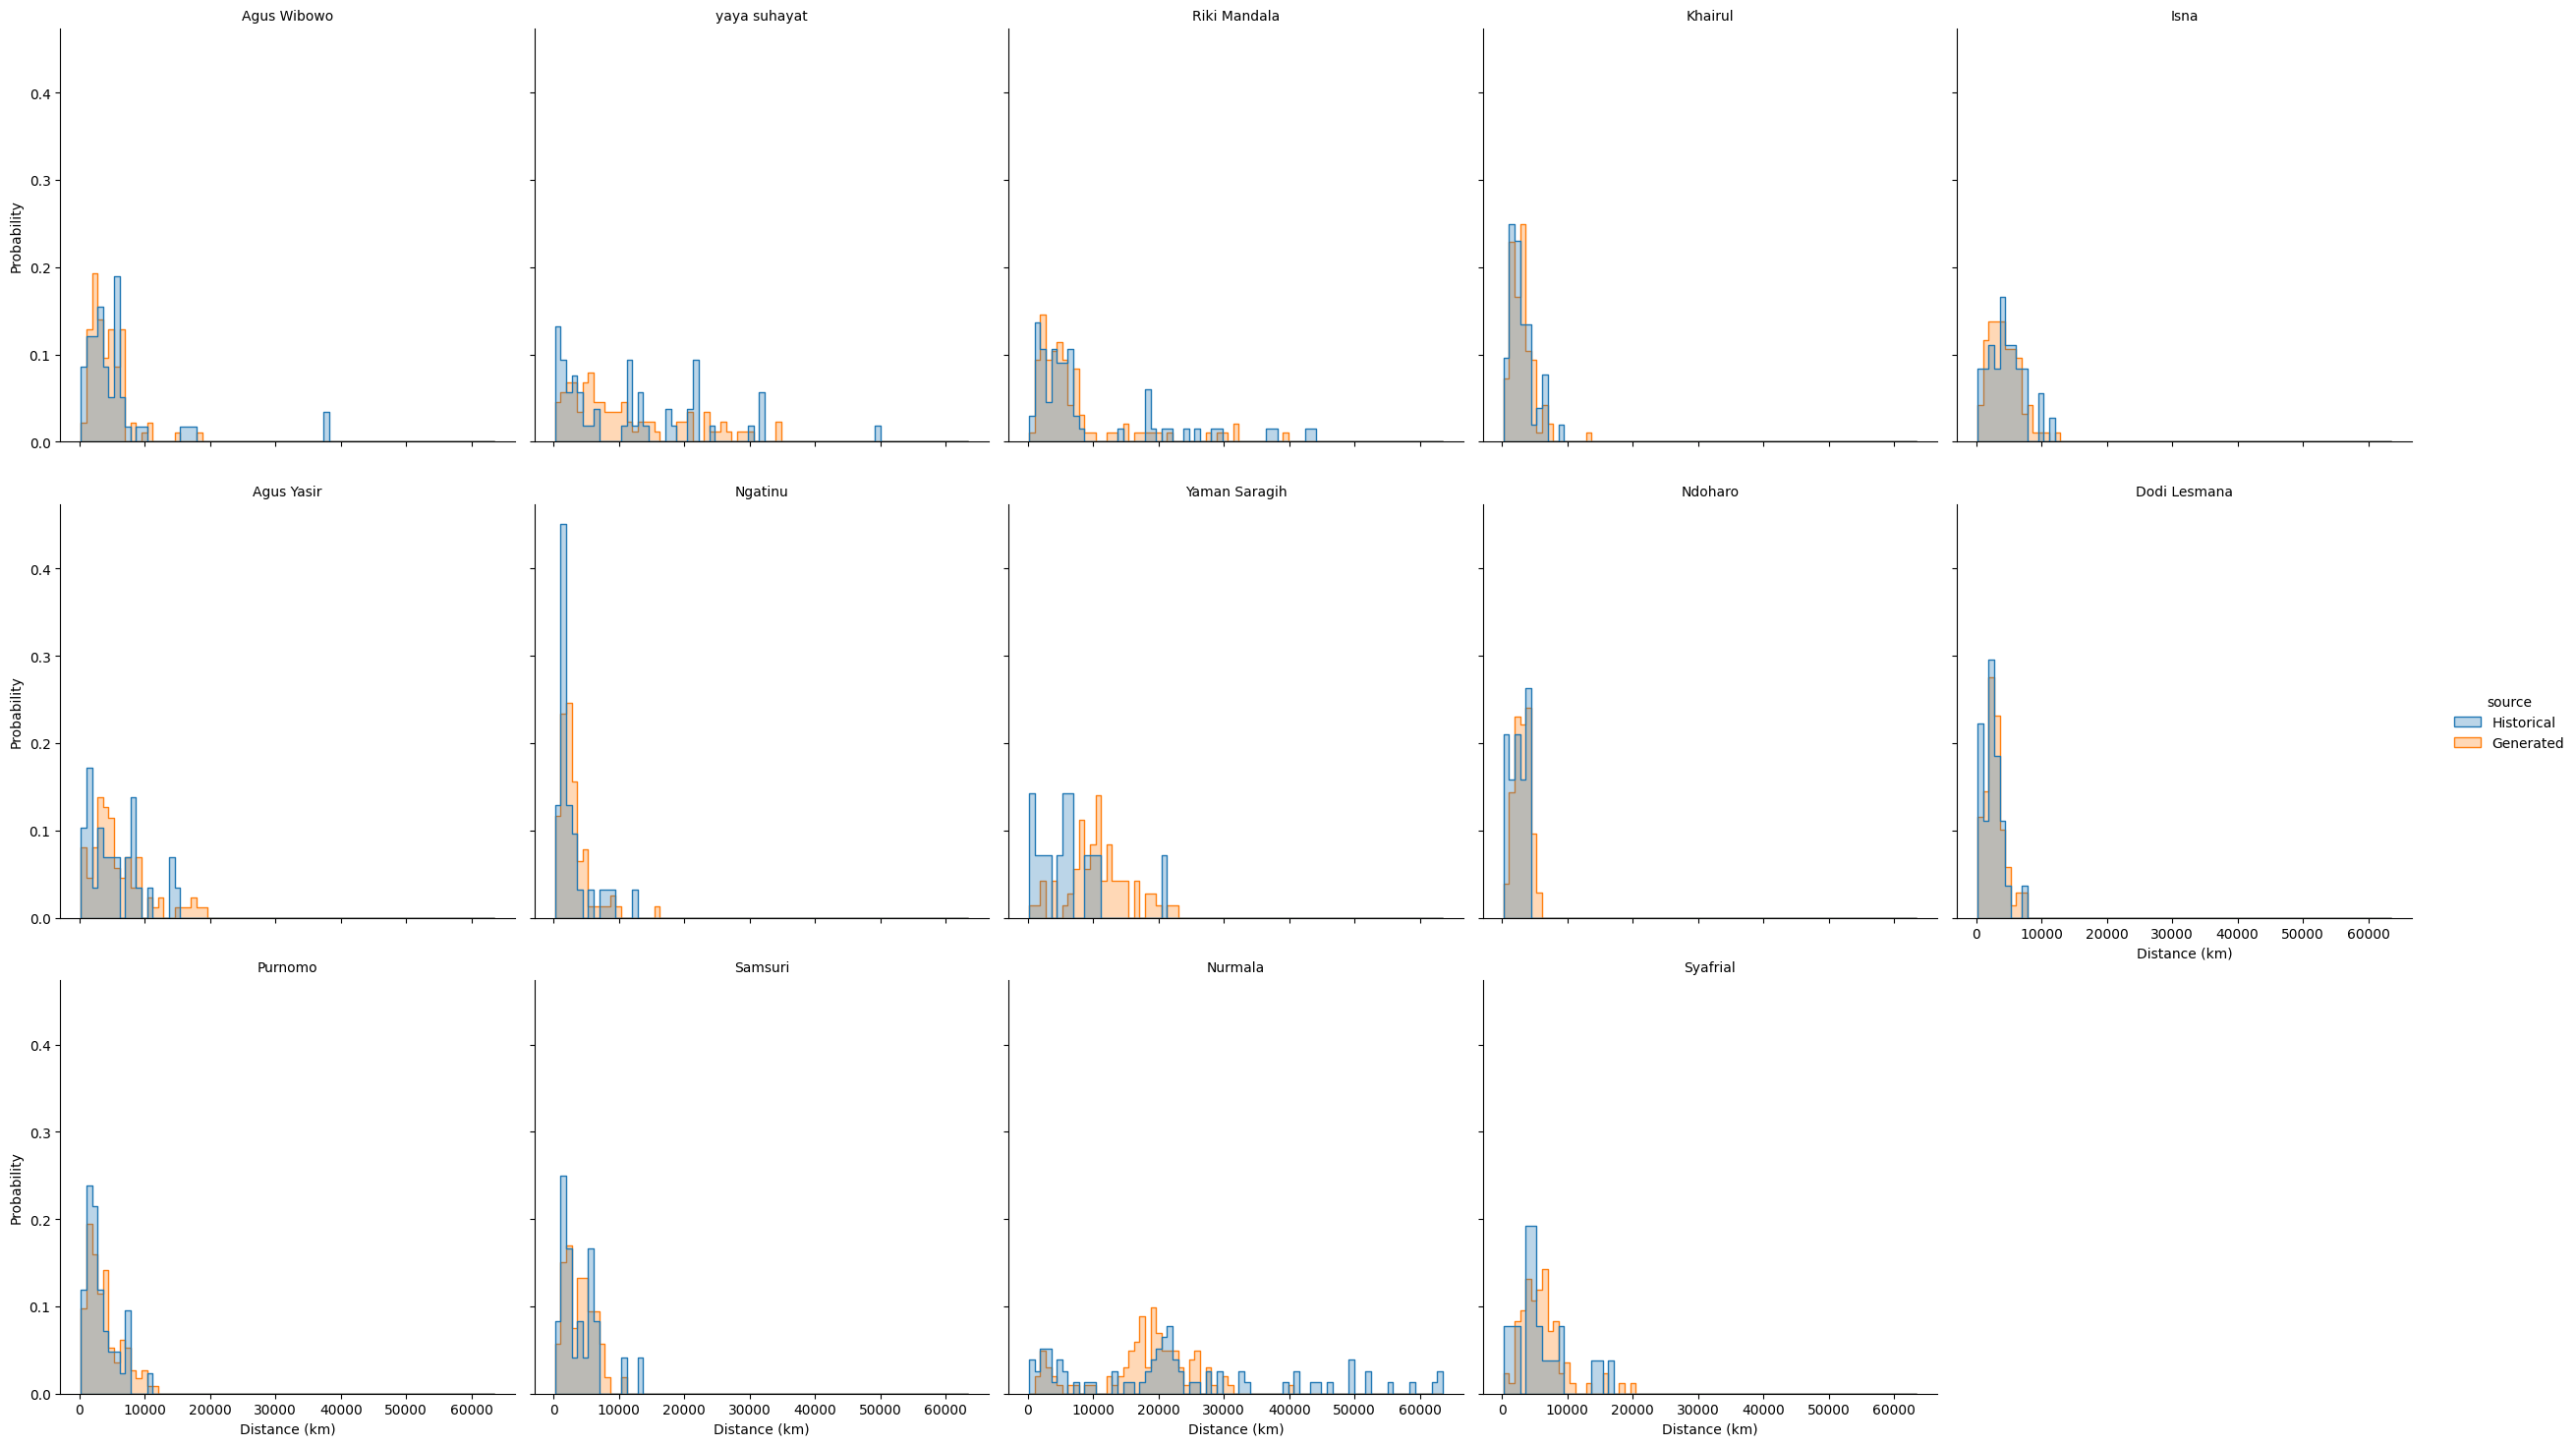

In [12]:
dist_hist = farmers_df.drop_duplicates(['int_id', 'farmer_x', 'farmer_y'])
dist_hist['source'] = 'Historical'

dist_gen = df.drop_duplicates(['int_id', 'farmer_x', 'farmer_y'])
dist_gen['source'] = 'Generated'

df_combined = pd.concat([dist_hist, dist_gen], ignore_index=True)


g = sns.displot(
    data=df_combined,
    x='distance',
    hue='source',
    col='int_id',
    col_wrap=5,
    stat='probability',
    common_norm=False,
    element='step',
    alpha=0.3,
    facet_kws={'sharex': True, 'sharey': True}
)

g.set_axis_labels("Distance (km)", "Probability")
g.set_titles("{col_name}")

g.figure.subplots_adjust(hspace=0.15)

# g.figure.suptitle('Distribution of farmer-intermediary distances', fontsize=14)
g.figure.subplots_adjust(top=0.965)

plt.show()


In [13]:
import networkx as nx
import osmnx as ox
import pandas as pd
from functools import lru_cache

# ---------------------------------------------------------
# 1. PRE-PROCESSING: Map nodes once to avoid redundant spatial queries
# ---------------------------------------------------------
def prepare_node_mapping(df_list, graph):
    """Maps unique farmer coordinates to graph nodes across all dataframes."""
    full_df = pd.concat([d[['farmer_x', 'farmer_y']] for d in df_list]).drop_duplicates()
    
    print(f"Mapping {len(full_df)} unique farmer locations to graph nodes...")
    full_df['node_id'] = ox.nearest_nodes(graph, full_df.farmer_x, full_df.farmer_y)
    
    return full_df

# ---------------------------------------------------------
# 2. CACHED DIJKSTRA: Memoize shortest path calculations
# ---------------------------------------------------------
@lru_cache(maxsize=10000)
def get_cached_distances(u, graph_id):
    """
    Computes and caches all-pairs distances from node u.
    graph_id is a dummy to ensure cache safety.
    """
    # Returns a dict of {target: distance}
    return nx.single_source_dijkstra_path_length(G_proj, u, weight='length')

# ---------------------------------------------------------
# 3. FAST TSP SOLVER
# ---------------------------------------------------------
def solve_road_tsp_fast(group, graph):
    """
    Solves TSP using cached distances and a greedy approximation.
    """
    # Filter nodes that actually exist in the graph
    nodes = [n for n in group['node_id'].unique() if n in graph]
    
    if len(nodes) < 2:
        return 0.0
    
    # Build distance matrix from cache
    dist_matrix = {}
    for u in nodes:
        # Fetching from cache is O(1) after first encounter
        all_dists = get_cached_distances(u, id(graph))
        dist_matrix[u] = {v: all_dists[v] for v in nodes if v in all_dists}

    valid_nodes = list(dist_matrix.keys())
    if len(valid_nodes) < 2:
        return 0.0

    # Create the complete graph for the TSP solver
    TSP_G = nx.Graph()
    for i, u in enumerate(valid_nodes):
        for v in valid_nodes[i+1:]:
            if v in dist_matrix[u]:
                TSP_G.add_edge(u, v, weight=dist_matrix[u][v])

    try:
        # greedy_tsp is much faster than Christofides (default) for large batches
        tsp_path = nx.approximation.traveling_salesman_problem(
            TSP_G, 
            cycle=False, 
            # method=nx.approximation.greedy_tsp
        )
        
        total_road_dist = sum(
            dist_matrix[tsp_path[i]][tsp_path[i+1]] 
            for i in range(len(tsp_path) - 1)
        )
        return total_road_dist
    except Exception:
        return -1.0

# ---------------------------------------------------------
# 4. WRAPPER FUNCTION
# ---------------------------------------------------------
def get_daily_tsp_dist(input_df, graph):
    """Groups data and calculates daily road distances."""
    # Group and apply the fast solver
    daily_dist = input_df.groupby(['int_id', 'date']).apply(
        lambda x: solve_road_tsp_fast(x, graph), 
        include_groups=False
    )
    
    # Filter and convert to KM
    res = daily_dist[daily_dist > 0].reset_index(name='km')
    res['km'] = res['km'] / 1000.0
    return res

# ---------------------------------------------------------
# 5. EXECUTION PIPELINE
# ---------------------------------------------------------

# First, map nodes once for both dataframes
node_map = prepare_node_mapping([farmers_df, df], G_proj)

# Join the mapping back to original data
hist_data = farmers_df.merge(node_map, on=['farmer_x', 'farmer_y'], how='left')
gen_data = df.merge(node_map, on=['farmer_x', 'farmer_y'], how='left')

print("Starting TSP calculations for Historical data...")
dist_hist = get_daily_tsp_dist(hist_data, G_proj)
dist_hist['source'] = 'Historical'

print("Starting TSP calculations for Generated data...")
dist_gen = get_daily_tsp_dist(gen_data, G_proj)
dist_gen['source'] = 'Generated'

# Combine results
df_combined = pd.concat([dist_hist, dist_gen], ignore_index=True)

NameError: name 'G_proj' is not defined

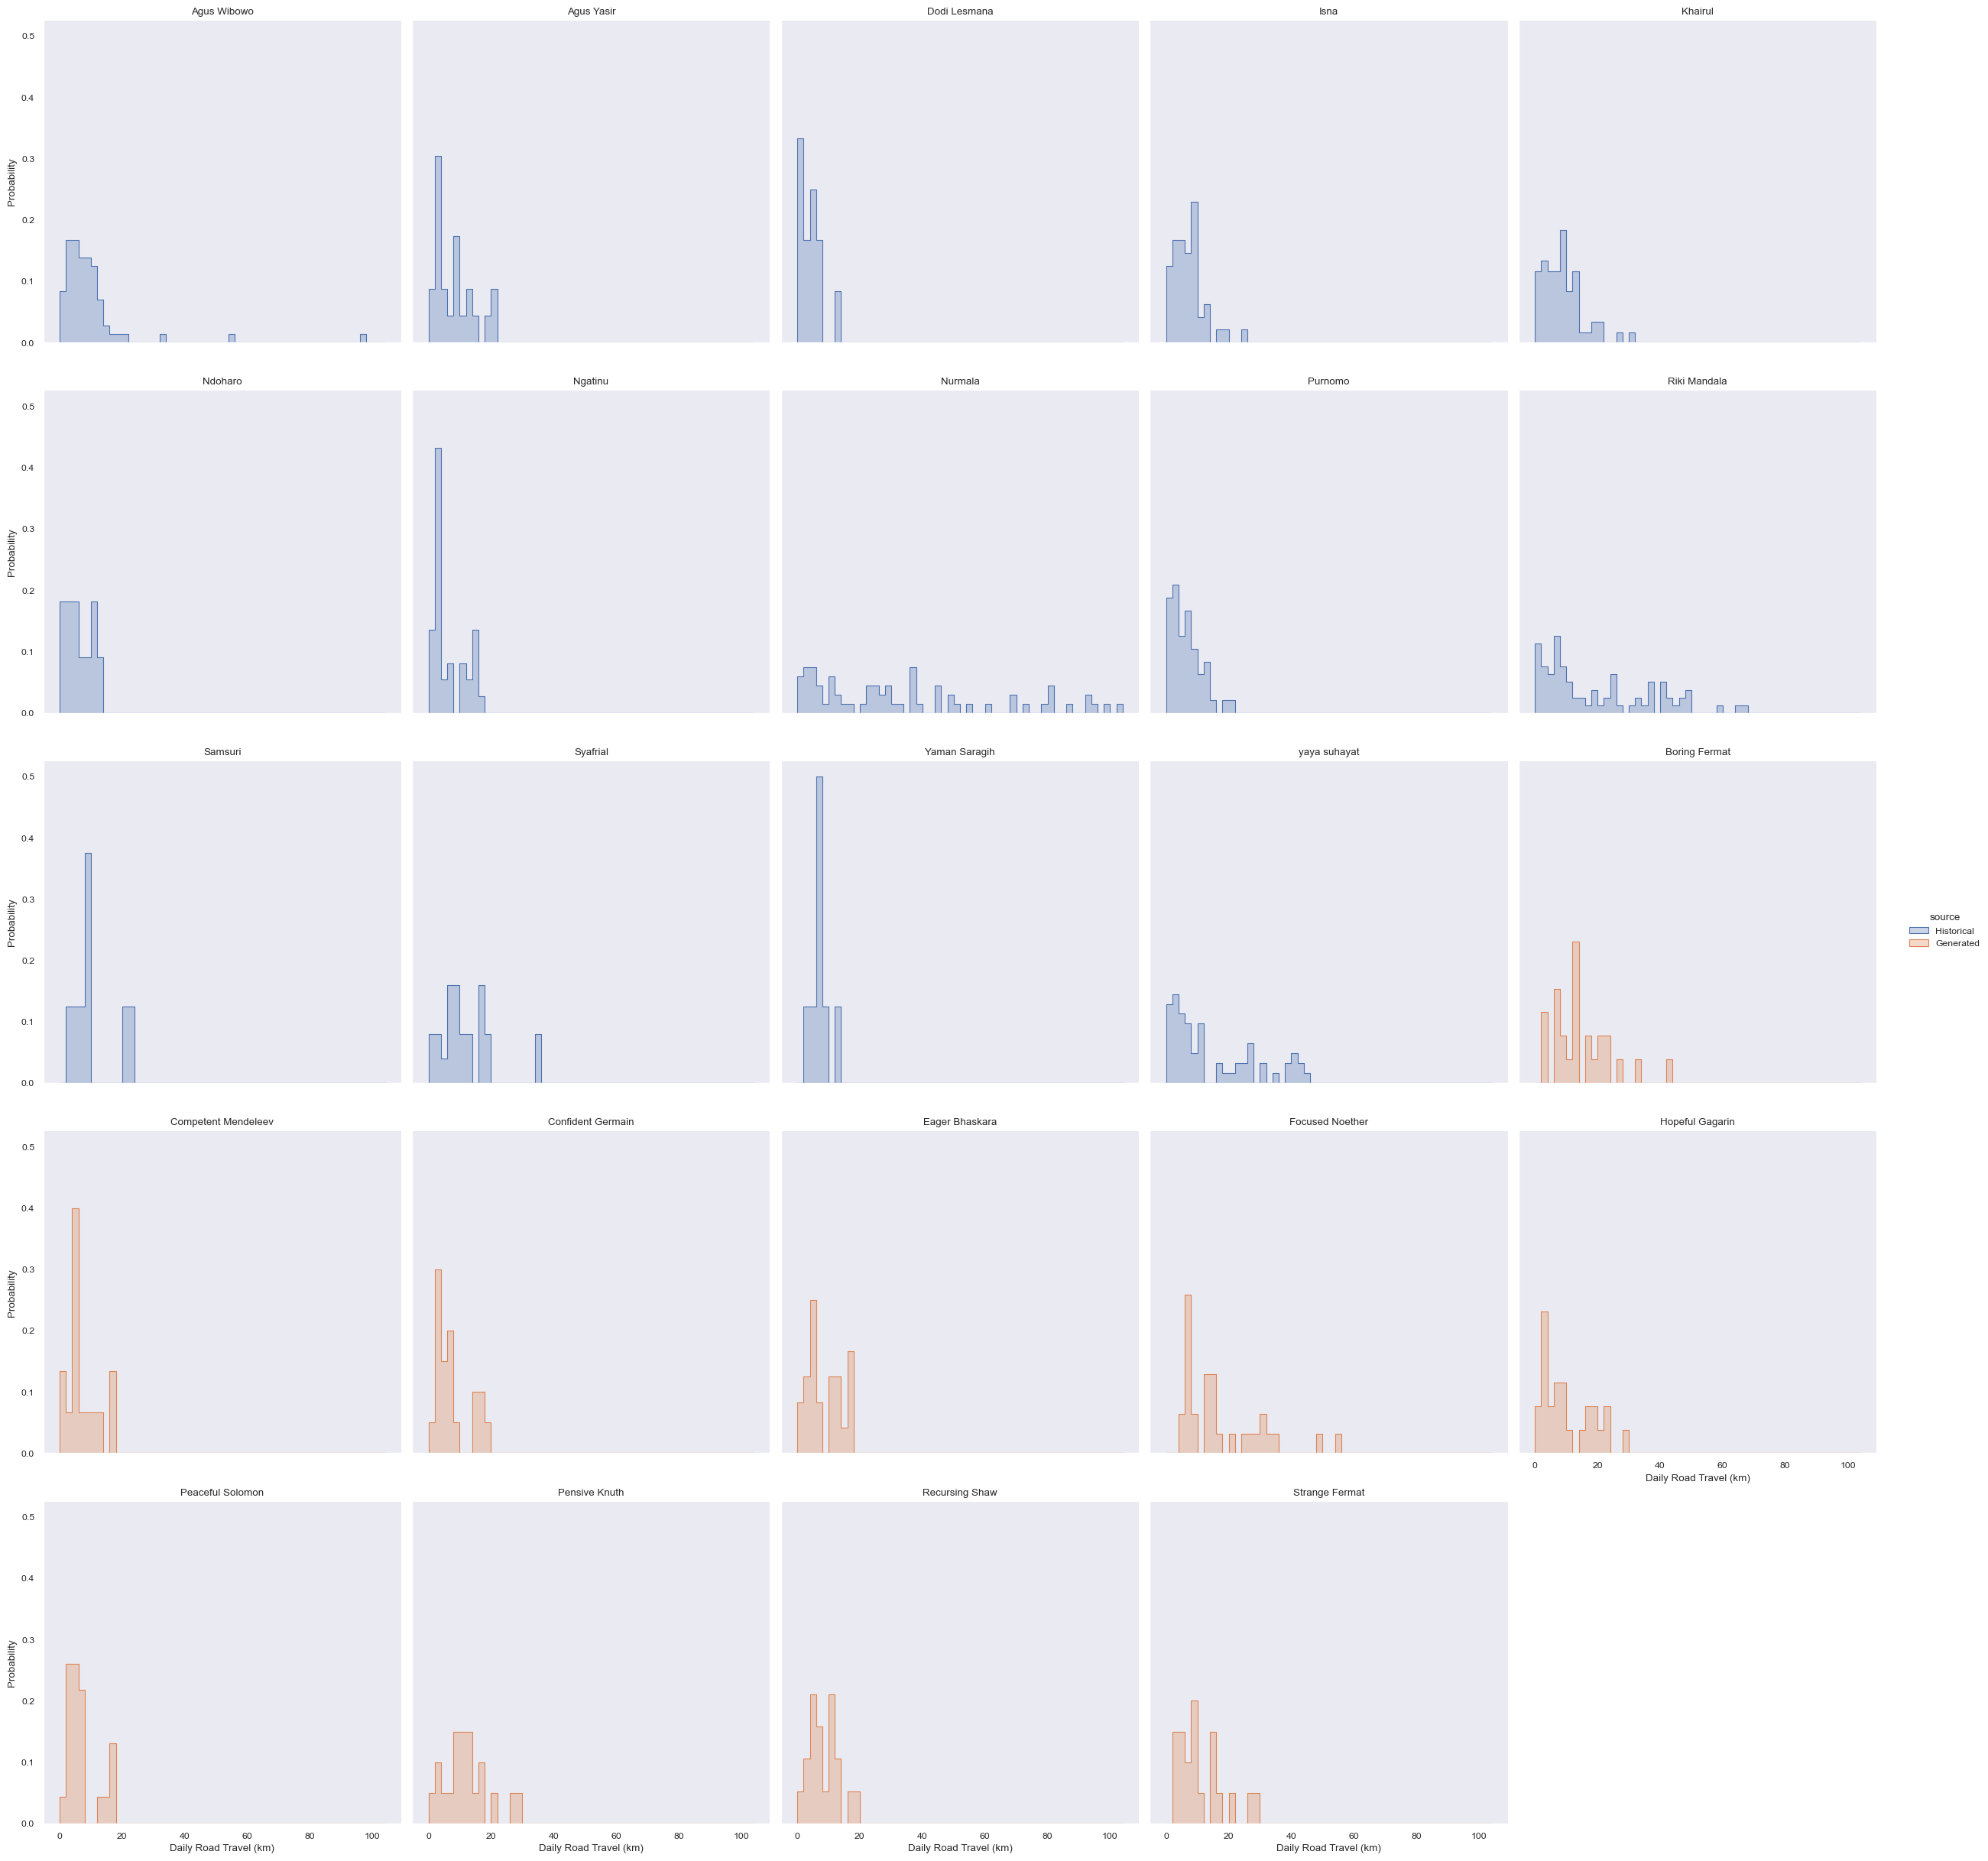

In [31]:
max_km = df_combined['km'].max()
bins = np.arange(0, max_km + 2, 2) # 2km bins for visibility

g = sns.displot(
    data=df_combined,
    x='km',
    hue='source',
    col='int_id',
    col_wrap=5,
    bins=bins,
    stat='probability',
    common_norm=False,
    element='step',
    alpha=0.3,
    facet_kws={'sharex': True, 'sharey': True}
)

# 5. Formatting
g.set_axis_labels("Daily Road Travel (km)", "Probability")
g.set_titles("{col_name}")

g.figure.subplots_adjust(hspace=0.15)

# g.figure.suptitle('Distribution of daily TSP tour length (by intermediary)', fontsize=14)
g.figure.subplots_adjust(top=0.965)

plt.show()